In [1]:
# Import Library
import sys
import pandas as pd
import numpy as np
import plotly.express as px
import plotly as py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler

from collections import Counter
from PIL import Image

import pandas as pd
from pathlib import Path

import calendar
!pip install termcolor
from termcolor import colored
from IPython.display import HTML

import warnings
warnings.filterwarnings("ignore")
py.offline.init_notebook_mode(connected = True)

In [2]:
# Import Dataset: kmeans_basic.csv
# Objective is to understand basic clustering
df1 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\3. 12-Apr-26_K_Means\kmeans_basic.csv")

In [3]:
df1.head()

,Feature1,Feature2
0,-7.430860,-7.899923
1,-7.912123,-7.341576
2,-1.522144,7.549274
3,4.378661,3.291702
4,-9.325377,-8.089813


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [5]:
print("Number of rows in dataset is: ", df1.shape[0])
print("Number of columns in dataset is: ", df1.shape[1])

Number of rows in dataset is:  300
Number of columns in dataset is:  2


In [6]:
# Step 1: Standardization and centering the data
scaler = StandardScaler()
X = scaler.fit_transform(df1)

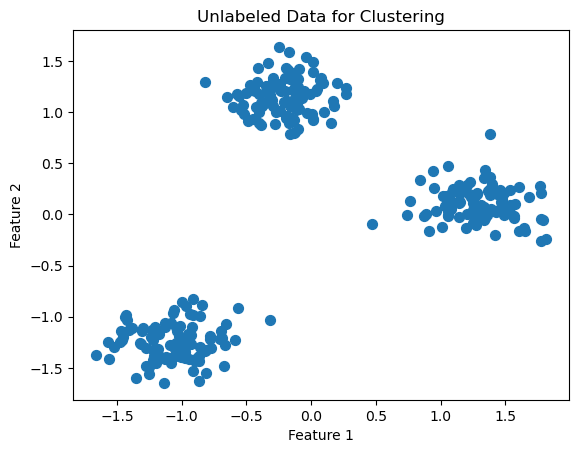

In [7]:
# Plot the data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Unlabeled Data for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [8]:
## Interpretation - Visually 03 clusters can be seen

In [9]:
# Steps involved in clustering 
# Goal: Goal: Partition data into k clusters by minimizing within-cluster variance.Key terms: Centroids, inertia (SSE), convergence.
# Step 1: Euclidean Distance Calculation
# Step 2: Initialize Random Centroids
# Step 3: Assign Each Point to Closest Centroid
# Step 4: Update Centroids Based on Assigned Points
# Step 5: Convergence Check

In [10]:
# Step 1: Euclidean Distance Calculation
def euclidean_distance(a, b):
    return np.linalg.norm(a - b, axis=1)

In [11]:
# Step 2: Initialize Random Centroids
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    # It uses NumPy to pick random row numbers from your data: 
    # len(X): Tells NumPy the range of numbers to pick from (e.g., if you have 100 rows, it picks between 0 and 99).
    # k: Tells NumPy exactly how many numbers to pick (e.g., 3).
    # replace=False: This is crucial. it ensures that the same row isn't picked twice. Every initial centroid must be a unique data point.
    
    return X[indices]
    # Now that we have the random row numbers, we go back to the original dataset X and grab the actual coordinates (the data) at those specific rows.
    # If your indices were [12, 45, 88], this returns the features of the 12th, 45th, and 88th rows as your starting centroids.

In [12]:
# Checking the output of step # 2, 
# by calling the function defined in step 2 and storing its result in a variable.
# Assuming your scaled data is named 'X' 
k = 3
centroids1 = initialize_centroids(X, k)

# Now print the result
print("Initial Centroids:")
print(centroids1)

Initial Centroids:
[[ 1.33561099  0.06934561]
 [-0.69134908 -1.21316442]
 [ 1.31138367  0.09501328]]


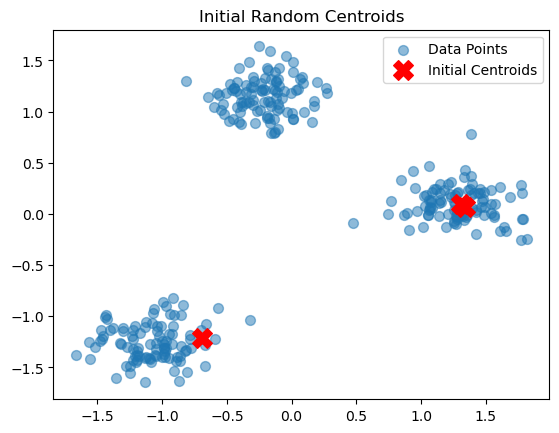

In [13]:
# Plotting where these random starting points landed:
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.5, label='Data Points')
plt.scatter(centroids1[:, 0], centroids1[:, 1], c='red', s=200, marker='X', label='Initial Centroids')
plt.title("Initial Random Centroids")
plt.legend()
plt.show()

In [14]:
#Step 3: Assign Each Point to Closest Centroid
def assign_clusters(X, centroids):
    clusters = []
    for point in X:
        distances = euclidean_distance(point, centroids) # Calculating distance for each individual point to all centroids
        cluster = np.argmin(distances) # it returns the index (the position) of the smallest distance, Example: If distances are [1.2, 0.5, 2.8], the smallest value is 0.5 at index 1.
        clusters.append(cluster) # stores that index (0, 1, or 2) in a list called clusters
    return np.array(clusters) # It converts the list into a NumPy array.

In [15]:
# Interpretation of step 3
# Use the function on your scaled data and the centroids you just created
labels = assign_clusters(X, centroids1)

# Look at the first 10 labels to see the cluster assignments (0, 1, or 2)
print("First 10 cluster assignments:")
print(labels[:10])

# Check how many points are in each cluster
unique, counts = np.unique(labels, return_counts=True)
print("\nPoints per cluster:", dict(zip(unique, counts)))

First 10 cluster assignments:
[1 1 2 2 1 0 2 0 2 2]

Points per cluster: {np.int64(0): np.int64(42), np.int64(1): np.int64(100), np.int64(2): np.int64(158)}


In [16]:
#Step 4: Update Centroids Based on Assigned Points
def update_centroids(X, labels, k):
    new_centroids = []
    for i in range(k): # The function loops through each cluster index (e.g., if k=3, it looks at cluster 0, 1, and 2).
        cluster_points = X[labels == i] # This uses Boolean indexing. It looks at entire dataset X and grabs only the rows where the label matches the current cluster i. If i=0, it pulls out all the (x, y) coordinates of the points currently assigned to Cluster 0.
        if len(cluster_points) == 0: # Sometimes, a centroid is so far away that zero points are assigned to it.
            # No points assigned to this cluster
            new_centroids.append(X[np.random.choice(len(X))]) # assign random point from the dataset. This prevents the code from crashing when it tries to calculate a mean of nothing.
        else:
            new_centroids.append(cluster_points.mean(axis=0)) # It calculates the average of all the points in that cluster along the column.
    return np.array(new_centroids) # It turns the list of new (x, y) coordinates back into a clean NumPy array 

In [17]:
# Centroids move from old to new
new_centroids = update_centroids(X, labels, k=3)
print("Old Centroids:\n", centroids1)
print("\nNew Centroids:\n", new_centroids)

Old Centroids:
 [[ 1.33561099  0.06934561]
 [-0.69134908 -1.21316442]
 [ 1.31138367  0.09501328]]

New Centroids:
 [[ 1.47968362  0.00566884]
 [-1.06790185 -1.25264527]
 [ 0.28255363  0.79130655]]


In [18]:
#Step 5: Convergence Check
def has_converged(old_centroids, new_centroids, tol=1e-4):
    return np.all(np.linalg.norm(old_centroids - new_centroids, axis=1) < tol)

In [19]:
# Now that you have all the individual building blocks (Initialization, Assignment, Updating, and Convergence), the next step is to combine them into a single loop
# This is where the algorithm will repeat the Assignment and Update steps automatically until the centroids stop moving or it hits a maximum number of iterations.
def kmeans(X, k, max_iters=100):
    # 1. Initialize
    centroids = initialize_centroids(X, k)
    
    for i in range(max_iters):
        # 2. Assign Clusters
        labels = assign_clusters(X, centroids)
        
        # 3. Update Centroids
        new_centroids = update_centroids(X, labels, k)
        
        # 4. Check for Convergence
        if has_converged(centroids, new_centroids):
            print(f"Converged at iteration {i}")
            break
            
        centroids = new_centroids
        
    return centroids, labels



In [20]:
# Execute the full algorithm, with K = 2
final_centroids1, final_labels = kmeans(X, k=2)

Converged at iteration 1


In [21]:
print(final_centroids1)

[[ 0.53395092  0.62632263]
 [-1.06790185 -1.25264527]]


In [22]:
# Execute the full algorithm
final_centroids2, final_labels = kmeans(X, k=3)
print(final_centroids2)

Converged at iteration 2
[[ 1.2830906   0.09947878]
 [-0.21518875  1.15316649]
 [-1.06790185 -1.25264527]]


In [23]:
# Execute the full algorithm, with K = 4
final_centroids3, final_labels = kmeans(X, k=4)
print(final_centroids2)

Converged at iteration 4
[[ 1.2830906   0.09947878]
 [-0.21518875  1.15316649]
 [-1.06790185 -1.25264527]]


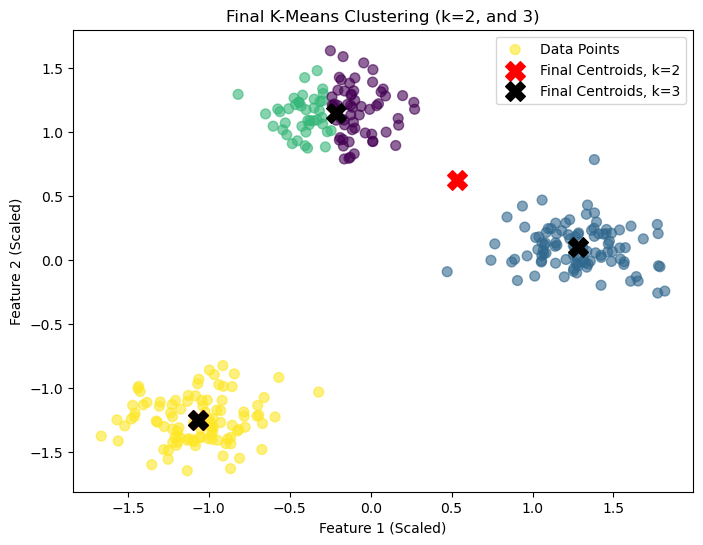

In [24]:
import matplotlib.pyplot as plt

# Create a scatter plot of the data points
# c=final_labels colors the points by their cluster assignment
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, s=50, cmap='viridis', alpha=0.6, label='Data Points')

# Plot the final centroids
plt.scatter(final_centroids1[:, 0], final_centroids1[:, 1], c='red', s=200, marker='X', label='Final Centroids, k=2')
plt.scatter(final_centroids2[:, 0], final_centroids2[:, 1], c='black', s=200, marker='X', label='Final Centroids, k=3')


plt.title(f"Final K-Means Clustering (k=2, and 3)")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.legend()
plt.show()

In [25]:
# Question 2: Which K gives the most meaningful grouping? Why? 
# Ans: K = 3 gives most meaningful grouping as this gives 03 clear distinct group with distance from centroid minimal
# Although there are 02 ways to measure this. 
# The Elbow Method (WSS): This is the most popular technique. It measures the Within-Cluster Sum of Squares (WSS), which is simply the sum of the squared distances between each point and its assigned centroid.
# Silhouette Coefficient: This is often considered more "meaningful" than the Elbow method because it measures both cohesion (how close a point is to its own cluster) and separation (how far it is from other clusters

In [26]:
# Question3: What do centroids represent in this dataset? 
# Ans: Centroid represents cluster center

In [27]:
# 2
# Import Dataset: kmeans_elbow.csv
# The Objective is to understand and find optimal K
df2 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\3. 12-Apr-26_K_Means\kmeans_elbow.csv")

In [28]:
df2.head()

,Feature1,Feature2
0,-12.039401,11.710508
1,-9.058560,11.069042
2,-9.452685,6.641714
3,7.077678,1.605526
4,6.067105,4.812084


In [29]:
# Checking for null values
df2.isna().sum()

Feature1    0
Feature2    0
dtype: int64

In [30]:
print("Number of rows in dataset is: ", df2.shape[0])
print("Number of columns in dataset is: ", df2.shape[1])

Number of rows in dataset is:  400
Number of columns in dataset is:  2


In [31]:
# Step 1: Standardization and centering the data
scaler = StandardScaler()
X = scaler.fit_transform(df2)

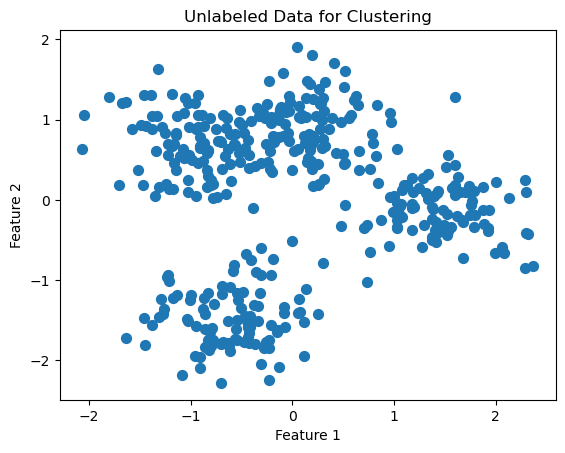

In [32]:
# Plot the data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Unlabeled Data for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Converged at iteration 1
Converged at iteration 6
Converged at iteration 5
Converged at iteration 6
Converged at iteration 7
Converged at iteration 17
Converged at iteration 12
Converged at iteration 13
Converged at iteration 11
Converged at iteration 6


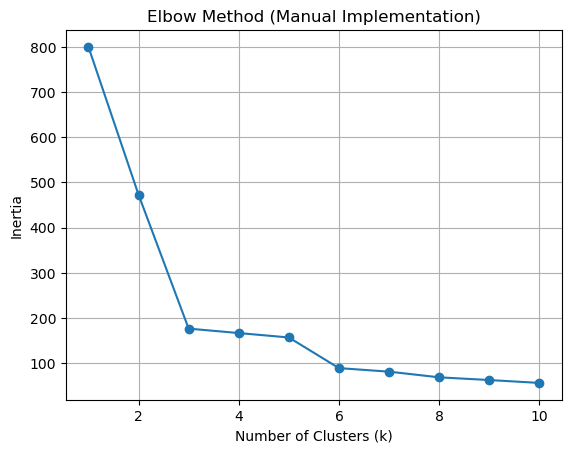

In [33]:
# Elbow method
def compute_inertia(X, labels, centroids):
    inertia = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        inertia += ((cluster_points - centroids[i])**2).sum()
    return inertia

# For each point in the cluster:

# 1. Compute the squared distance from the point to its cluster centroid
# 2. Sum these distances for the cluster
# 3. Add that sum to the total inertia


inertias = []
ks = range(1, 11)
for k in ks:
    c, l = kmeans(X, k)
    inertias.append(compute_inertia(X, l, c))

plt.plot(ks, inertias, marker='o')
plt.title("Elbow Method (Manual Implementation)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [34]:
# Questions
# 1. Identify the “elbow point” in the graph 
# Answer: Elbow is at k = 8
# 2. Why does inertia always decrease as K increases? 
# Answer: Inertia measures the squared distances of data points to their closest cluster centroid. As $K$ increases, more centroids are added, meaning data points will always find a centroid that is closer to them (or at the same distance). In the extreme case where $K$ equals the total number of data points, each point becomes its own cluster center, and the inertia drops to 0.
# 3. Is the elbow point clearly visible? What does that imply? 
# Answer: Elbow point represents the number of cluster centers after which change in WCSS (within cluster sum of squares) becomes minimal. 

In [35]:
# 3
# Import Dataset: Dataset: kmeans_init.csv
# The Objective is to understand and study initialization effect
df3 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\3. 12-Apr-26_K_Means\kmeans_init.csv")

In [36]:
# Checking null values
df3.isna().sum()

Feature1    0
Feature2    0
dtype: int64

In [37]:
# Standardization and centering the data
scaler = StandardScaler()
X = scaler.fit_transform(df3)

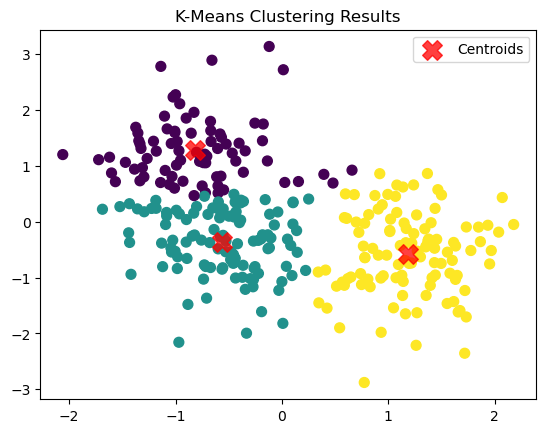

In [38]:
# Import Library
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title("K-Means Clustering Results")
plt.legend()
plt.show()

Random State = 10, 
cluster centers are: 
[[-0.52737996 -0.39647879]
 [-0.83888295  1.21645255]
 [ 1.18561305 -0.57952007]]
Random State = 42, 
cluster centers are: 
[[-0.81420218  1.28086512]
 [-0.56169674 -0.35608073]
 [ 1.18561305 -0.57952007]]
Random State = 99, 
cluster centers are: 
[[-0.83888295  1.21645255]
 [ 1.18561305 -0.57952007]
 [-0.52737996 -0.39647879]]


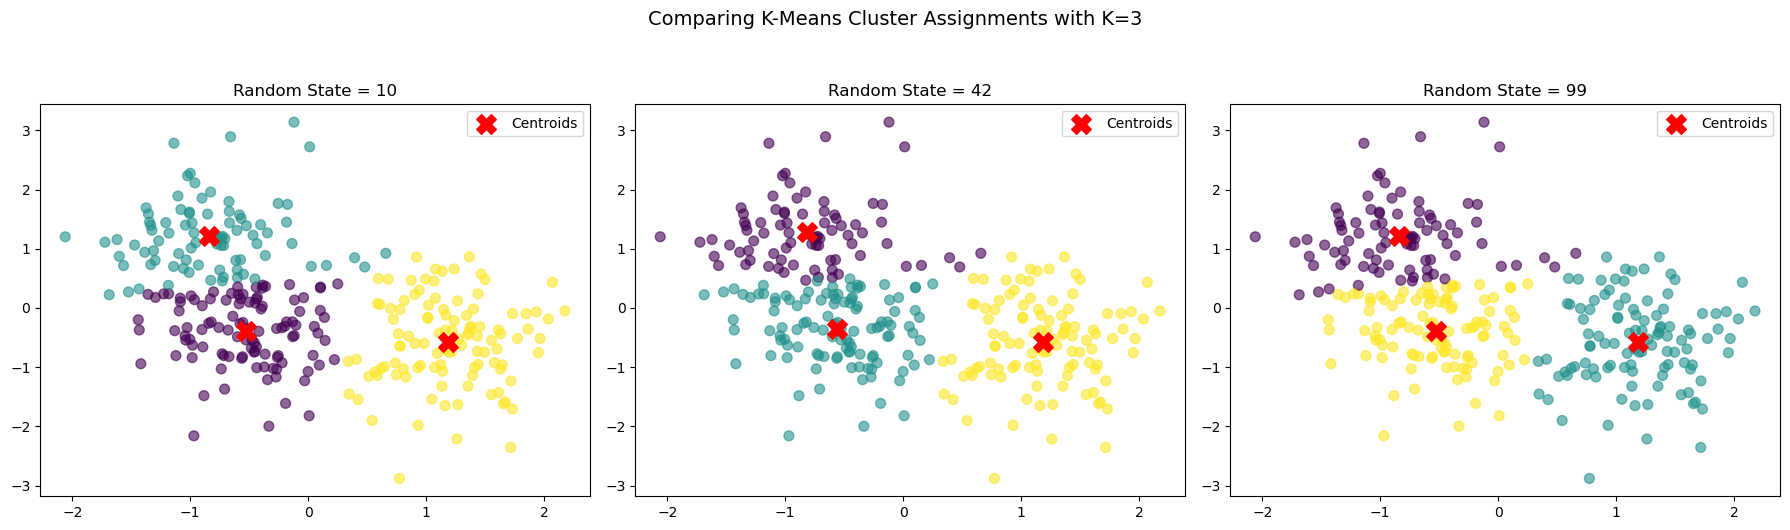

In [39]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Fix K = 3 as requested by the assignment prompt
K_fixed = 3

# Define a list of different random states to test
random_states = [10, 42, 99]

# Create a figure to plot the different results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, state in enumerate(random_states):
    # 1. Initialize KMeans with a fixed K but a different random_state
    kmeans_test = KMeans(n_clusters=K_fixed, random_state=state)
    
    # 2. Fit and predict on your standardized data X
    y_pred = kmeans_test.fit_predict(X)
    centers = kmeans_test.cluster_centers_
    
    # 3. Plot the resulting clusters on the corresponding subplot
    axes[i].scatter(X[:, 0], X[:, 1], c=y_pred, s=50, cmap='viridis', alpha=0.6)
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
    
    # Fixed: Perfect 4-space indentation alignment & removed 'value='
    axes[i].set_title(f"Random State = {state}")
    axes[i].legend()
    print(f"Random State = {state}, \ncluster centers are: \n{centers}")

plt.suptitle(f"Comparing K-Means Cluster Assignments with K={K_fixed}", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [40]:
# Questions:
# 1. Run K-means multiple times with different random states 
# 2. Keep K fixed (e.g., K = 3) 
# 3. Compare cluster assignments 

In [41]:
# 4
# Import Dataset: kmeans_scaling.csv
# The Objective is to understand scaling impact
df4 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\3. 12-Apr-26_K_Means\kmeans_scaling.csv")

In [42]:
# Checking for null vales
df4.isna().sum()

Feature1    0
Feature2    0
dtype: int64

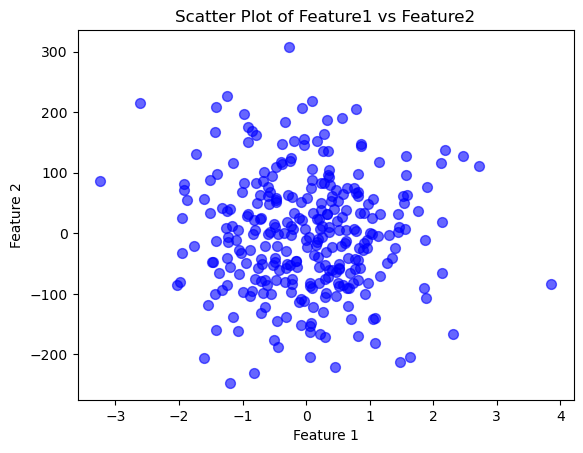

In [43]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.scatter(df4['Feature1'], df4['Feature2'], alpha=0.6, c='blue', s=50)

# Add labels and a title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Feature1 vs Feature2')

# Display the plot
plt.show()

In [44]:
print("minimum values of:\n", df4.min())
print("maximum values of:\n", df4.max())

minimum values of:
 Feature1     -3.241267
Feature2   -247.164450
dtype: float64
maximum values of:
 Feature1      3.852731
Feature2    307.888081
dtype: float64


In [45]:
# Findings
# Feature 1 and Feature have 02 different scales 

In [46]:
# Task: 
# Apply K-means: 
#	Without scaling 
#	With standardization 
#	Compare clustering results 

In [47]:
# Extract features into an array
X_unscaled = df4[['Feature1', 'Feature2']].values

K = 2 => Inertia: 999547.21, Silhouette: 0.5504
K = 3 => Inertia: 523670.28, Silhouette: 0.5274
K = 4 => Inertia: 310336.44, Silhouette: 0.5406
K = 5 => Inertia: 189198.04, Silhouette: 0.5574
K = 6 => Inertia: 146403.90, Silhouette: 0.5455
K = 7 => Inertia: 105634.79, Silhouette: 0.5446
K = 8 => Inertia: 85285.50, Silhouette: 0.5395
K = 9 => Inertia: 65137.63, Silhouette: 0.5450


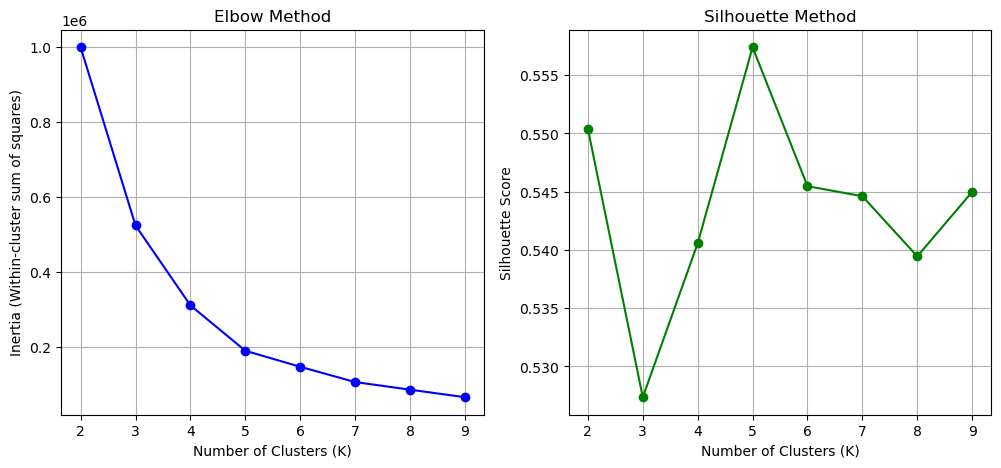

In [48]:
# Initialize lists
inertias = []               # For Elbow Method
silhouette_scores = []      # For Silhouette Method
K_range = range(2, 10)

# Loop through possible K values
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_unscaled)

    # Elbow Method: store inertia
    inertias.append(kmeans.inertia_)

    # Silhouette Method: store silhouette score
    sil_score = silhouette_score(X_unscaled, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} => Inertia: {kmeans.inertia_:.2f}, Silhouette: {sil_score:.4f}")

# Plot Elbow Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

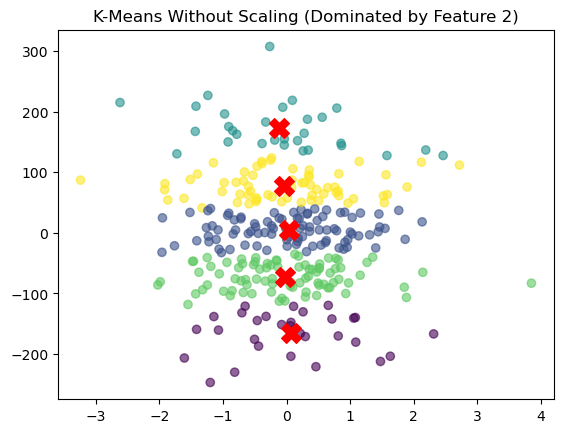

In [49]:
# Selecting number of clusters = 5, based on Slhouette score 
from sklearn.cluster import KMeans

# Fit K-Means
kmeans_unscaled = KMeans(n_clusters=5, random_state=42).fit(X_unscaled)
y_pred_unscaled = kmeans_unscaled.predict(X_unscaled)

# Plotting the unscaled result
plt.scatter(X_unscaled[:, 0], X_unscaled[:, 1], c=y_pred_unscaled, cmap='viridis', alpha=0.6)
plt.scatter(kmeans_unscaled.cluster_centers_[:, 0], kmeans_unscaled.cluster_centers_[:, 1], c='red', s=200, marker='X')
plt.title("K-Means Without Scaling (Dominated by Feature 2)")
plt.show()

In [50]:
# Center and scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X_unscaled)


K = 2 => Inertia: 408.76, Silhouette: 0.3039
K = 3 => Inertia: 276.45, Silhouette: 0.3299
K = 4 => Inertia: 219.67, Silhouette: 0.3101
K = 5 => Inertia: 189.22, Silhouette: 0.2910
K = 6 => Inertia: 164.87, Silhouette: 0.2923
K = 7 => Inertia: 137.28, Silhouette: 0.3074
K = 8 => Inertia: 124.16, Silhouette: 0.3088
K = 9 => Inertia: 110.96, Silhouette: 0.3016


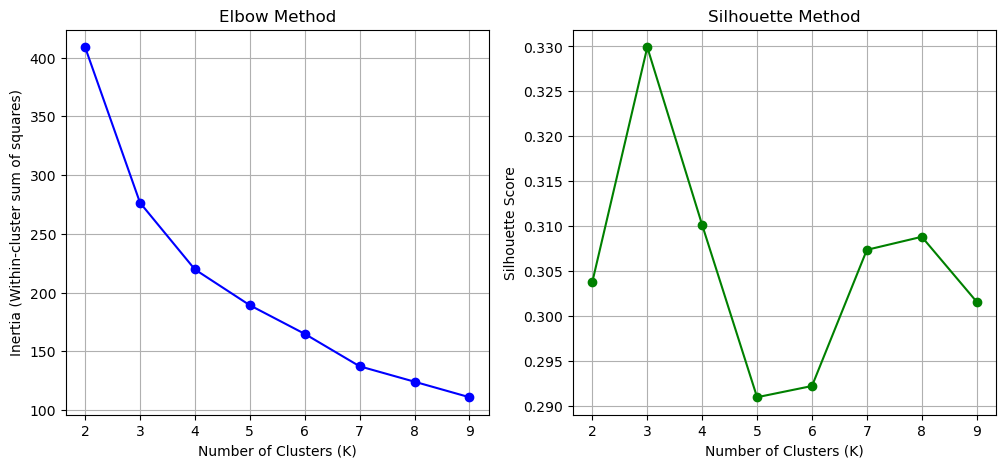

In [51]:
# Calculate k on scaled data
# Initialize lists
inertias = []               # For Elbow Method
silhouette_scores = []      # For Silhouette Method
K_range = range(2, 10)

# Loop through possible K values
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)

    # Elbow Method: store inertia
    inertias.append(kmeans.inertia_)

    # Silhouette Method: store silhouette score
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} => Inertia: {kmeans.inertia_:.2f}, Silhouette: {sil_score:.4f}")

# Plot Elbow Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

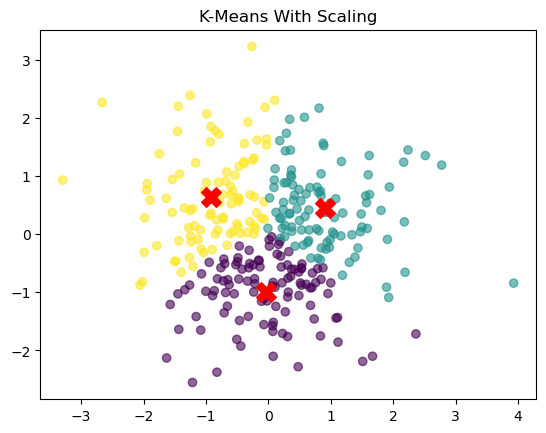

In [52]:
# Number of clusters are 3
# Selecting number of clusters = 3, based on Slhouette score 
from sklearn.cluster import KMeans

# Fit K-Means
kmeans_scaled = KMeans(n_clusters=3, random_state=42).fit(X)
y_pred_scaled = kmeans_scaled.predict(X)

# Plotting the scaled result
plt.scatter(X[:, 0], X[:, 1], c=y_pred_scaled, cmap='viridis', alpha=0.6)
plt.scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1], c='red', s=200, marker='X')
plt.title("K-Means With Scaling")
plt.show()


In [53]:
# Questions
#1.	How do cluster assignments differ before and after scaling? 
# Ans: Before scaling as per Silhoutte score, there was 5 clusters and after scaling the silhoutte scores suggest maximum value at cluster center = 3
#2.	Which feature dominates before scaling? Why? 
# Ans: Feature 2 was dominating before of the large value compared to feature 1. 
#3.	Why is scaling important for distance-based algorithms? 
# Ans: Distance-based algorithms (like K-Means, K-Nearest Neighbors, and Hierarchical Clustering) use geometric distance formulas—most commonly Euclidean Distance—to measure how similar or different data points are from one another. 
# If features are unscaled, the distance formula is completely dominated by features with larger magnitudes (like Feature 2). This makes the algorithm mathematically blind to smaller-scale features, distorting the cluster boundaries. Scaling ensures all features contribute equally to the distance calculation.

In [54]:
# 5
# Import Dataset: kmeans_nonlinear.csv
# The Objective is to understand and Identify K-means limitation
df5 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\3. 12-Apr-26_K_Means\kmeans_nonlinear.csv")

In [55]:
# Checking for null
df5.isna().sum()

Feature1    0
Feature2    0
dtype: int64

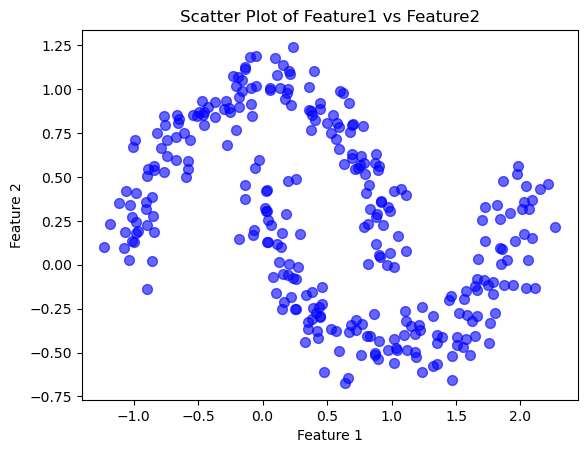

In [56]:
# Create the scatter plot
plt.scatter(df5['Feature1'], df5['Feature2'], alpha=0.6, c='blue', s=50)

# Add labels and a title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Feature1 vs Feature2')

# Display the plot
plt.show()

In [57]:
# Data is non linear

In [66]:
# Extract features into an array
X = df5[['Feature1', 'Feature2']].values

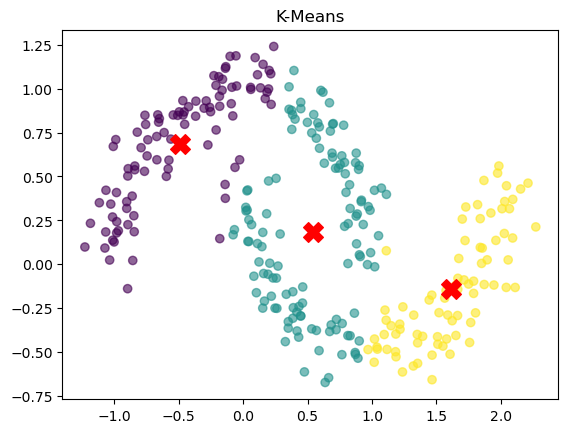

In [67]:
# Number of clusters are 3
# Selecting number of clusters = 3, based on Slhouette score 
from sklearn.cluster import KMeans

# Fit K-Means
kmeans_scaled = KMeans(n_clusters=3, random_state=42).fit(X)
y_pred_scaled = kmeans_scaled.predict(X)

# Plotting the result
plt.scatter(X[:, 0], X[:, 1], c=y_pred_scaled, cmap='viridis', alpha=0.6)
plt.scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1], c='red', s=200, marker='X')
plt.title("K-Means")
plt.show()

In [68]:
# The reason for seeing a straight line is that K-Means is a linear classifier. 
# It partitions data spaces using a mathematical boundary called a Voronoi diagram, which always creates perfectly straight lines (or hyperplanes) to separate clusters.
# 

In [69]:
# Can we use Spectral Clustering and Kernel K means?

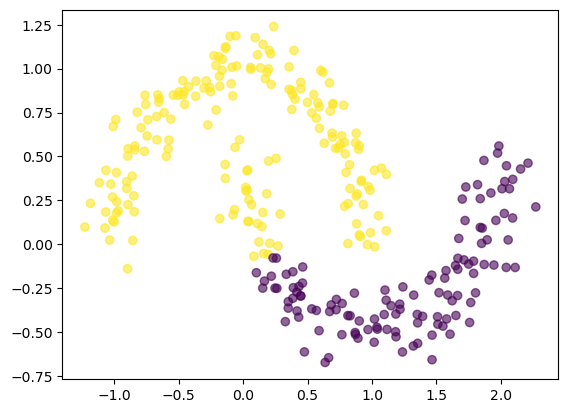

In [70]:
# Spectral Clustering
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt

# Initialize the model for your non-linear dataset
# 'nearest_neighbors' forces the algorithm to prioritize local connectivity
model = SpectralClustering(
    n_clusters=2, 
    affinity='nearest_neighbors', 
    n_neighbors=15
)

# Fit and predict the clusters
labels = model.fit_predict(X)

# Plot your newly uncurved clusters!
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.show()


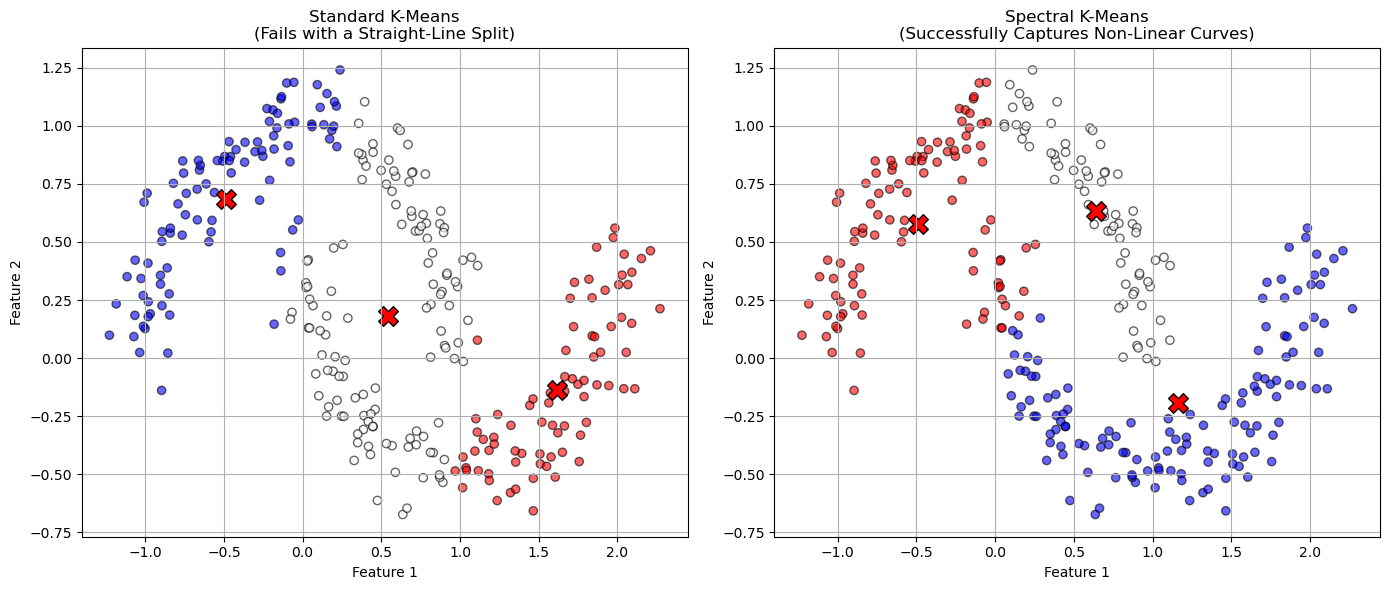

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering, KMeans

# 1. Apply Spectral K-Means (Spectral Clustering)
spectral_kmeans = SpectralClustering(
    n_clusters=3, 
    affinity='nearest_neighbors', 
    n_neighbors=10, 
    assign_labels='kmeans', 
    random_state=42
)
spectral_labels = spectral_kmeans.fit_predict(X)

# 2. Calculate explicit centers for Spectral Clustering in the original 2D space
spectral_centers = np.array([X[spectral_labels == i].mean(axis=0) for i in range(3)])

# 3. Plot and Compare the Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Standard K-Means Plot ---
ax1.scatter(X[:, 0], X[:, 1], c=y_pred_scaled, cmap='bwr', alpha=0.6, edgecolors='k')
# Drawing original K-means centers
ax1.scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1], 
            c='red', s=200, marker='X', edgecolors='black')
ax1.set_title("Standard K-Means\n(Fails with a Straight-Line Split)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.grid(True)

# --- Spectral K-Means Plot ---
ax2.scatter(X[:, 0], X[:, 1], c=spectral_labels, cmap='bwr', alpha=0.6, edgecolors='k')
# Drawing calculated Spectral centers
ax2.scatter(spectral_centers[:, 0], spectral_centers[:, 1], 
            c='red', s=200, marker='X', edgecolors='black')
ax2.set_title("Spectral K-Means\n(Successfully Captures Non-Linear Curves)")
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [73]:
# Spectral Clustering works by transforming your non-linear data into a lower-dimensional embedding space (using eigenvectors) where the data becomes linearly separable. 
# It then runs K-Means inside that abstract embedding space.Because the centroids are calculated inside that hidden mathematical space, they don't map directly back to your original (X, Y) coordinates for Feature 1 and Feature 2.
# Since you can't easily plot an abstract centroid, the cleanest way to show "centers" on your original non-linear data is to find the medoid (the average geometric center of each discovered cluster group)

In [74]:
# 6
# Import Dataset: kmeans_highdim.csv
# The Objective is to understand and work with high-dimensional data
df6 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\3. 12-Apr-26_K_Means\kmeans_highdim.csv")

In [79]:
df6.columns

Index(['F1', 'F2', 'F3', 'F4', 'F5', 'F6'], dtype='object')

In [76]:
# checking for null
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      400 non-null    float64
 1   F2      400 non-null    float64
 2   F3      400 non-null    float64
 3   F4      400 non-null    float64
 4   F5      400 non-null    float64
 5   F6      400 non-null    float64
dtypes: float64(6)
memory usage: 18.9 KB


In [81]:
# Extract features into an array
X_unscaled = df6[['F1', 'F2', 'F3', 'F4', 'F5', 'F6']].values

In [82]:
# Step 1: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

In [103]:
from sklearn.decomposition import PCA

# 1. Initialize PCA 
# Keeping n_components=None initially will calculate all 6 possible components
pca = PCA(n_components=None, random_state=42)

# 2. Fit and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# 3. Calculate Explained Variance
explained_variance = pca.explained_variance_ratio_

# 4. Print out the variance retained by each component
print("Explained variance by each component:")
for i, variance in enumerate(explained_variance):
    print(f"Principal Component {i+1}: {variance*100:.2f}%")

print(f"\nTotal variance explained by first 3 components: {sum(explained_variance[:3])*100:.2f}%")

Explained variance by each component:
Principal Component 1: 67.80%
Principal Component 2: 21.30%
Principal Component 3: 7.93%
Principal Component 4: 1.84%
Principal Component 5: 0.67%
Principal Component 6: 0.47%

Total variance explained by first 3 components: 97.03%


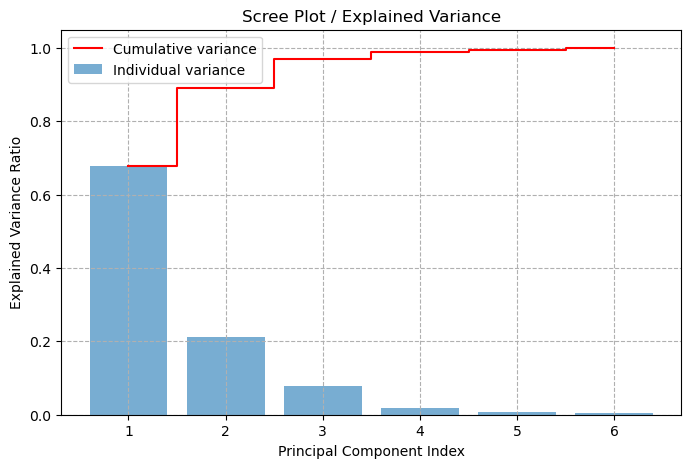

In [85]:
# To easily see where the "elbow" occurs (the point where adding more components doesn't give much more information),
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(range(1, 7), explained_variance, alpha=0.6, align='center', label='Individual variance')
plt.step(range(1, 7), np.cumsum(explained_variance), where='mid', label='Cumulative variance', color='red')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Scree Plot / Explained Variance')
plt.xticks(range(1, 7))
plt.legend(loc='best')
plt.grid(True, linestyle='--')
plt.show()

In [89]:
print(X_pca)

[[ 2.21504333  0.87493145 -0.50548588  0.21386846  0.39926596 -0.20332633]
 [-2.58722893  0.62108898  0.61003203  0.04029903  0.23602249  0.27694704]
 [-2.24329925  0.67872529  0.67811194  0.34222195  0.28972239 -0.17887324]
 ...
 [-2.74837603  0.79894878  0.46836635  0.14421193  0.21776898  0.05358701]
 [ 1.41927897 -1.69462721  0.79414785 -0.05423757  0.28566964 -0.12101959]
 [ 1.54032037 -1.69359603  0.93344617 -0.23267223  0.16991176 -0.06667585]]


In [99]:
print(X_pca[:, 0][:5])

[ 2.21504333 -2.58722893 -2.24329925  1.4171928  -0.990427  ]


In [100]:
print(X_pca[:, 1][:5])

[ 0.87493145  0.62108898  0.67872529 -1.59523076 -0.53169122]


In [92]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Extract the first two principal components from X_pca
# X_pca[:, 0] is PC1, X_pca[:, 1] is PC2
X_pca_2d = X_pca[:, :2]

K = 2 => Inertia: 1044.17, Silhouette: 0.5640
K = 3 => Inertia: 238.06, Silhouette: 0.7473
K = 4 => Inertia: 39.20, Silhouette: 0.8312
K = 5 => Inertia: 34.38, Silhouette: 0.7104
K = 6 => Inertia: 32.50, Silhouette: 0.7060
K = 7 => Inertia: 28.73, Silhouette: 0.5879
K = 8 => Inertia: 24.61, Silhouette: 0.4738
K = 9 => Inertia: 21.27, Silhouette: 0.3576


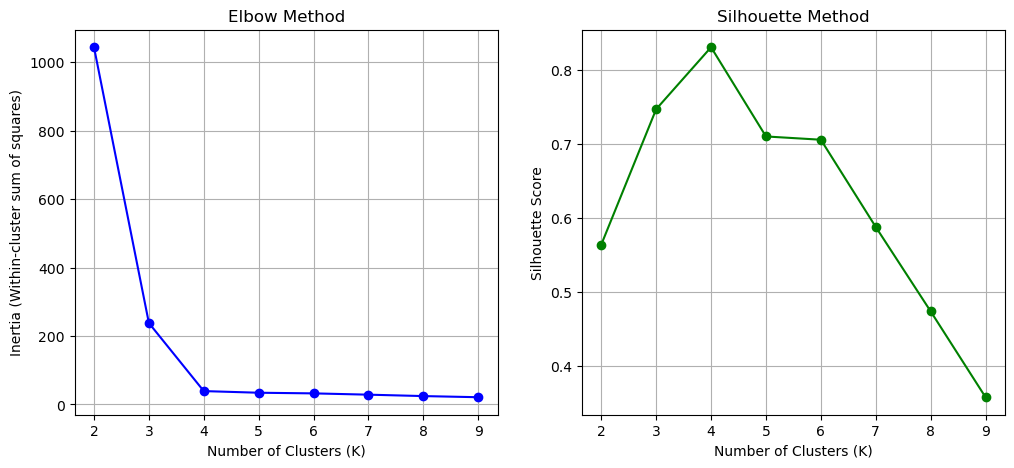

In [93]:
# Calculate k on scaled data
# Initialize lists
inertias = []               # For Elbow Method
silhouette_scores = []      # For Silhouette Method
K_range = range(2, 10)

# Loop through possible K values
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_pca_2d)

    # Elbow Method: store inertia
    inertias.append(kmeans.inertia_)

    # Silhouette Method: store silhouette score
    sil_score = silhouette_score(X_pca_2d, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} => Inertia: {kmeans.inertia_:.2f}, Silhouette: {sil_score:.4f}")

# Plot Elbow Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

Silhouette Score for 4 clusters on 2D PCA data: 0.8312


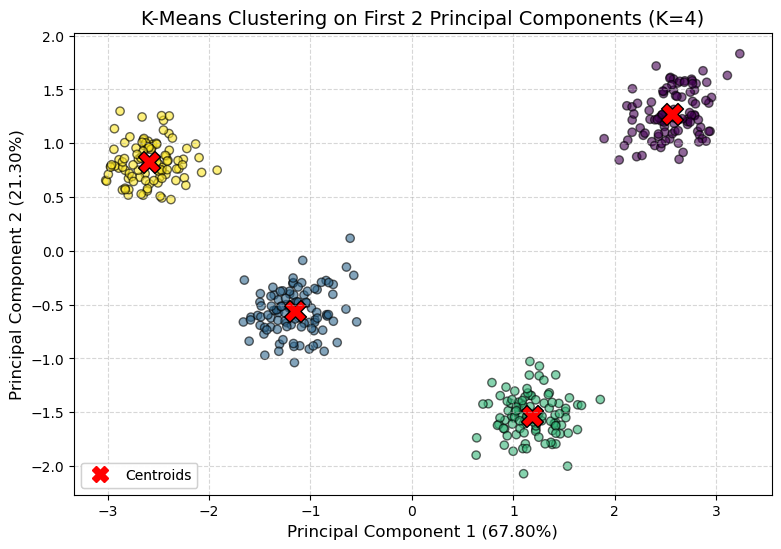

In [94]:
# 2. Initialize and fit K-Means
# (Adjust n_clusters based on your elbow/silhouette analysis)
num_clusters = 4 
kmeans_pca = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42)
pca_labels = kmeans_pca.fit_predict(X_pca_2d)

# 3. Calculate Silhouette Score to evaluate the clustering quality
score = silhouette_score(X_pca_2d, pca_labels)
print(f"Silhouette Score for {num_clusters} clusters on 2D PCA data: {score:.4f}")

# 4. Plot the clustered PCA data
plt.figure(figsize=(9, 6))

# Scatter plot of the data points colored by cluster
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                      c=pca_labels, cmap='viridis', alpha=0.6, edgecolors='k')

# Plot the cluster centers (centroids)
centroids = kmeans_pca.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', s=250, marker='X', edgecolors='black', label='Centroids')

# Formatting the plot
plt.title(f'K-Means Clustering on First 2 Principal Components (K={num_clusters})', fontsize=14)
plt.xlabel('Principal Component 1 (67.80%)', fontsize=12)
plt.ylabel('Principal Component 2 (21.30%)', fontsize=12)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
plt.gca().add_artist(plt.legend(handles=[plt.Line2D([0], [0], marker='X', color='red', linestyle='', markersize=12, label='Centroids')], loc='lower left'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Questions:
#1.	Why is PCA needed for visualization? 
#2.	Are clusters clearly visible after projection? 
#3.	Does dimensionality reduction affect interpretation? 


Composition Matrix for Principal Component 1:
Feature  PC1 Loading Weight
     F4            0.461932
     F5           -0.459899
     F1           -0.457027
     F2            0.453150
     F3            0.358872
     F6            0.179172


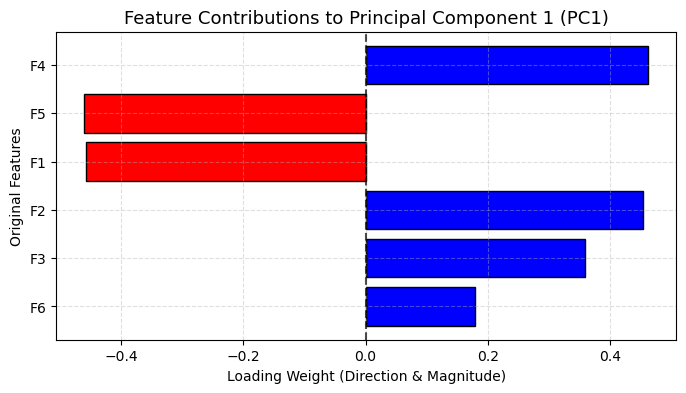

In [101]:
# explain the composition of Principal Component 1 (PC1) by original 6 features (F1 to F6), you need to look at what data scientists call PCA Loadings (or components weights).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the loadings matrix (components_ attribute holds the weights)
# Row 0 corresponds to PC1, Row 1 corresponds to PC2, etc.
pc1_loadings = pca.components_[0]

# 2. Create a clean DataFrame mapping features to their PC1 weights
# (Assuming your original features are named F1 to F6)
feature_names = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6']
pc1_composition = pd.DataFrame({
    'Feature': feature_names,
    'PC1 Loading Weight': pc1_loadings
})

# Sort by absolute value to see the most influential features first
pc1_composition['Absolute Weight'] = pc1_composition['PC1 Loading Weight'].abs()
pc1_composition = pc1_composition.sort_values(by='Absolute Weight', ascending=False).drop(columns=['Absolute Weight'])

print("Composition Matrix for Principal Component 1:")
print(pc1_composition.to_string(index=False))

# 3. Plot the composition
plt.figure(figsize=(8, 4))
colors = ['red' if w < 0 else 'blue' for w in pc1_composition['PC1 Loading Weight']]
plt.barh(pc1_composition['Feature'], pc1_composition['PC1 Loading Weight'], color=colors, edgecolor='k')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.title('Feature Contributions to Principal Component 1 (PC1)', fontsize=13)
plt.xlabel('Loading Weight (Direction & Magnitude)')
plt.ylabel('Original Features')
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().invert_yaxis() # Highest impact at the top
plt.show()